# ADALL Practical: Preparing Data and Building a Baseline Model

**Module:** AI-driven Analytics with Large Language Models  
**Audience:** CET students  
**Platform:** Google Colab  
**Class time:** 2 sessions × 130 minutes

This notebook follows a simple story:

1. Understand the business problem.
2. Inspect the dataset yourself.
3. Use an LLM carefully, by sending only selected information.
4. Clean the dataset using clear decisions.
5. Build a baseline model.
6. Evaluate the model and suggest simple improvements.

### Colour guide used in this practical

| Colour | Meaning |
|---|---|
| <font color='red'>Red</font> | Important note, assessment warning, or common mistake |
| <font color='blue'>Blue</font> | Student activity or prompt to try |
| **Normal text** | Main explanation and code guidance |

The practical is shorter than the original reference notebook, but it keeps the original scaffolding style, colour-coded reminders, illustrations, and key explanations.


---

## <font color='red'>Note: ADALL assessment: Practical Test – Keep It Simple</font>

Do not worry about advanced techniques or be overwhelmed by complicated code you may see in labs.
For the practical test, you are expected to perform **simple and familiar tasks**.

The practical test focuses on whether you can:

* follow a basic data analytics workflow,
* apply steps you have already practised in class,
* write clear, sensible code,
* explain what each step does in simple terms.

You are **not** expected to solve complex problems or optimise everything.

---

## <font color='red'>Note: Why You See More Complex Code in Labs</font>

In labs, you may see richer examples than what is needed in a practical test.
This is done on purpose.

The lab:

* exposes you to patterns used in real projects,
* prepares you for industry-style tasks and pet projects,
* helps you recognise more complex workflows when you see them later.

You are **not expected** to reproduce all of this complexity in a practical test.

---


## Session timing overview

| Session | Target time | Main outcome |
|---|---:|---|
| Session 1 | 130 minutes | From business problem to clean dataset |
| Session 2 | 130 minutes | From cleaned dataset to baseline model, evaluation, and files for manual GitHub upload |

The timings are realistic classroom timings. Some students may finish faster, but the extra time is used for checking, discussion, and explanation.

---
# Session 1: From business problem to clean dataset

**Target duration:** 130 minutes

By the end of Session 1, you should be able to explain:

- what the dataset is about,
- what the target column is,
- why we should not send the full dataset to an LLM,
- what payload text contains,
- how to make a simple cleaning decision from dataset evidence.


## How this version is written

This session keeps the original colour style and images.

The code is kept beginner-friendly where possible:

- simple variable names,
- one action per block,
- fewer helper functions,
- fewer nested expressions,
- clear checks after important cells.

The goal is not to make the shortest code.

The goal is to make code that a learner can explain.


## Chapter 1. Setup and load libraries

**Suggested time:** 3 minutes

Run this first. These libraries support data handling, plotting, modelling, and payload text creation.


In [ ]:
# Libraries used in this notebook
import os
import shutil
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Modelling libraries used later in Session 2
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# Make wide tables easier to read in Colab
pd.set_option('display.max_columns', 100)

## Chapter 2. Load the dataset

**Suggested time:** 5 minutes

For this lab, use the dataset url given to you.

For your own assignment, change the url to your own dataset.

In [ ]:
github_raw_url = 'https://raw.githubusercontent.com/rq-goh/ADALL_github/refs/heads/main/laptop_prices_2024_sgd_TL.csv'

df = pd.read_csv(github_raw_url)

print('Dataset loaded successfully.')
print('Shape:', df.shape)
display(df.head())

# This cell loads the laptop price dataset directly from GitHub.
# The GitHub raw URL points to the actual CSV file, not the normal GitHub preview page.
# pd.read_csv() reads the CSV file and stores it as a pandas DataFrame called df.
# df.shape shows the number of rows and columns in the dataset.
# df.head() displays the first 5 rows so we can quickly check that the data loaded correctly.

## Chapter 3. LLM-assisted problem framing

**Suggested time:** 15 minutes

## <font color='red'>Note: What is important in this section</font>

You need to show that you understand the difference between a **business problem** and a **modelling objective**.

In a practical test, you may be asked to translate a simple scenario into a clear and measurable modelling task.
Focus on identifying:

* the target variable,
* the end user,
* the value the model creates,
* the main risk if the model is used wrongly.

A **business problem** is written in normal business language.  
A **modelling objective** is more technical and tells us what we want the model to predict.

| Type | Example |
|---|---|
| Business problem | A refurbished laptop seller wants to price laptops fairly and consistently. |
| Modelling objective | Build a regression model to predict `Price_SGD` using laptop specifications such as brand, CPU, GPU, RAM, storage, screen size, and weight. |

### <font color='blue'>Activity: Prompt to use with an LLM</font>

You can copy and adapt this prompt:

> You are an expert data scientist with experience in tree-based regression models.  
> Help me translate this business problem into a modelling objective.  
>  
> Business problem: A refurbished laptop seller wants to price laptops fairly and consistently.  
> Dataset context: The dataset contains laptop specifications and price in SGD.  
>  
> Please answer:  
> 1. What should the modelling objective be?  
> 2. What is the most meaningful target column?  
> 3. Which metric would be easiest to explain to business users?  
> 4. Who are the main stakeholders?  
> 5. What are three risks or pitfalls?

### Example answer

A short and practical answer could be:

> **Modelling objective:** Build a regression model to predict the fair laptop price in SGD using laptop specifications.  
> **Target:** `Price_SGD`.  
> **Metric:** MAE, because it can be explained as the average dollar error.  
> **Stakeholders:** pricing team, procurement team, product analysts.  
> **Risks:** target leakage, outdated hardware trends, and brand or market bias.

The exact answer may differ depending on the LLM, but it should still be clear, measurable, and linked to the business use.


## Chapter 4. Quick dataset inspection before using an LLM

**Suggested time:** 8 minutes

Before using an LLM or building a model, inspect the dataset yourself.

You are checking:

1. How many rows and columns there are.
2. What the first few rows look like.
3. Which columns are numeric or categorical.
4. Whether any obvious data quality issue appears.

This is a quick orientation step, not a full analysis.

<font color='blue'>Activity:</font> Run the next three cells and write down what you notice before asking the LLM.


In [ ]:
print('Shape:', df.shape)
display(df.head())

In [ ]:
df.info()

In [ ]:
df.columns.tolist()

### Mini-check

Answer these before moving on:

1. Which column are we trying to predict?
2. Which columns look numeric?
3. Which columns look categorical?
4. Do you see any columns that may be discounts, IDs, or repeated constants?


## Chapter 5. First LLM touchpoint: send only a small preview

**Suggested time:** 15 minutes

Now that you have inspected the data yourself, you can ask an LLM for a first reading of the dataset.

We start with a small preview because it is easy to understand. The preview gives the LLM the column names and a few example rows.

### <font color='red'>Important boundary</font>

Creating `data_preview` below does **not** send anything to the LLM yet. It only creates a text version of the first 10 rows inside Colab.

The data is only sent when we run the API cell that calls `client.responses.create(...)`.

### Example

If you write a sentence on paper, it has not been emailed to anyone.  
It is only sent when you click send.  
Here, the API call is the “send” step.


<font color='blue'>Activity:</font> After printing the preview, decide whether 10 rows are enough to describe the whole dataset. Be ready to explain why not.

In [ ]:
data_preview = df.head(10).to_string()
print(data_preview[:1500])

### Set up the API connection

This lab can be completed in two ways:

1. Copy the prompt and paste it into the ChatGPT website manually.
2. Use the OpenAI API from Colab if your class account has been set up.

The default setting below uses the manual method because it is simpler and safer for beginners.

If your tutor asks you to use the API, change `RUN_API_CELLS` to `True` and run the API setup lines.

In [ ]:
# Default method: copy the prompt into the chatbot manually.
RUN_API_CELLS = True
OPENAI_MODEL = 'gpt-5.4-nano'
client = None

# Only use this section if your tutor has asked you to call the API from Colab.
# You must first save OPENAI_API_KEY in Colab Secrets.

if RUN_API_CELLS == True:
    from google.colab import userdata
    from openai import OpenAI

    api_key = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=api_key)
    print('OpenAI client is ready.')
else:
    print('Manual chatbot mode. Copy the prompts when they appear.')

# This cell prepares the notebook to use the OpenAI API, if needed.
# RUN_API_CELLS controls whether the notebook uses the API or manual chatbot mode.
# If RUN_API_CELLS is True, the notebook will try to connect to OpenAI using an API key.
# If RUN_API_CELLS is False, students can copy the prompt and paste it into ChatGPT manually.
# OPENAI_MODEL stores the model name that will be used later when sending prompts.
# client starts as None first, then becomes an OpenAI client after the API key is loaded.
# userdata.get('OPENAI_API_KEY') reads the API key saved in Colab Secrets.
# OpenAI(api_key=api_key) creates the connection object used to call the API.

In [ ]:
preview_prompt = f"""
Here are the first 10 rows of a laptop pricing dataset:

{data_preview}

Questions:
1. What does each row appear to represent?
2. Which column is likely the target for a price prediction model?
3. What are 3 possible data quality checks we should perform before modelling?

Keep the answer short and practical.
"""

print('Prompt to send:')
print(preview_prompt[:2000])

if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=preview_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

# This cell creates a prompt for the LLM using the first 10 rows of the dataset.
# The f-string allows Python to insert data_preview directly into the prompt text.
# The prompt asks the LLM to inspect the dataset and give simple modelling-readiness comments.
# preview_prompt[:2000] prints only the first 2000 characters so the output is not too long.
# If client is connected, the prompt is sent to the OpenAI API using the selected model.
# response.output_text prints the LLM's answer in the notebook.
# If client is not connected, students can copy the printed prompt and paste it into ChatGPT manually.

### Limitation of the 10-row preview

A preview is useful, but it may not represent the whole dataset.

Example: if the first 10 rows are all gaming laptops, the LLM may wrongly assume that the whole dataset is mostly gaming laptops.

This is why we next build a **payload text** summary of the whole dataset.


## Chapter 6. Payload text: the main ADALL idea

**Suggested time:** 14 minutes

Instead of sending the full dataset, we can send a **dataset profile**.

In this notebook, the dataset profile is called `payload_text`.

### Standard definition

In this practical, **payload text** means a compact text summary of the dataset that is prepared locally in Python and sent to the LLM as context.

### Why use payload text?

| Approach | Strength | Weakness |
|---|---|---|
| Send 10 rows | Easy to understand | May not represent the full dataset |
| Send full dataset | More complete | Costly, slow, privacy risk, too large |
| Send payload text | Balanced summary | LLM sees summary, not every row |

### What payload text usually contains

| Payload section | What it helps the LLM notice | Simple example |
|---|---|---|
| Shape | Dataset size | 1,000 rows, 15 columns |
| Data types | Numeric or categorical columns | `RAM_GB` is numeric, `Brand` is categorical |
| Numeric summary | Ranges, averages, spread | `Price_SGD` min, max, mean |
| Missing values | Columns that may need cleaning | `GPU` has missing entries |
| Unique values | IDs, constant columns, high-cardinality columns | `Laptop_ID` may be unique for every row |
| Correlations | Numeric columns that move together | RAM and price may be related |
| Outliers | Unusual values to inspect | Very expensive laptop |
| Value counts | Common categories | Top brands or CPU types |

You do **not** need to memorise every line of the payload-building code. You need to understand what information is being summarised and why.

| Payload block | What it tells the LLM |
|---|---|
| `SHAPE` | Number of rows and columns |
| `DTYPES` | Which columns are numeric, text, or other types |
| `MISSING VALUES` | Which columns may need cleaning |
| `NUMERIC SUMMARY` | Typical range and spread of numeric columns |
| `CATEGORICAL SUMMARY` | Common categories and high-cardinality columns |
| `CORRELATION` | Numeric columns that move together |
| `OUTLIER SUMMARY` | Columns with unusual extreme values |

<font color='blue'>Activity:</font> When you print the payload, identify three sections that you understand and one section that needs clarification.


## Chapter 7. Build the payload text

**Suggested time:** 12 minutes

Run the code below. It creates a dataset profile as one long text string.

This version is written in a beginner-friendly way. It avoids helper functions and builds the payload one part at a time.

The payload includes:

- number of rows and columns,
- column names and data types,
- numeric summary,
- missing values,
- unique counts,
- correlations,
- top values for categorical columns,
- simple warning checks.

The lecturer usually explains this at **block level**, not line by line.

### What to check after running

Check that the printed payload mentions:

1. the dataset shape,
2. numeric columns,
3. categorical columns,
4. missing values,
5. possible warning columns.


In [ ]:
# Build payload text step by step.
# Payload text is a short profile of the dataset.
# It is safer and smaller than sending the full dataset to the LLM.

payload_text = ''

# 1. Shape
payload_text += '=== SHAPE ===\n'
payload_text += 'Rows: ' + str(df.shape[0]) + '\n'
payload_text += 'Columns: ' + str(df.shape[1]) + '\n\n'

# 2. Column names and data types
payload_text += '=== COLUMNS AND DATA TYPES ===\n'
payload_text += df.dtypes.to_string()
payload_text += '\n\n'

# 3. Numeric summary
payload_text += '=== NUMERIC SUMMARY ===\n'
numeric_summary = df.describe(include='number').round(2)
payload_text += numeric_summary.to_string()
payload_text += '\n\n'

# 4. Missing values
payload_text += '=== MISSING VALUES ===\n'
missing_table = pd.DataFrame()
missing_table['missing_count'] = df.isna().sum()
missing_table['missing_pct'] = (df.isna().sum() / len(df) * 100).round(2)
payload_text += missing_table.to_string()
payload_text += '\n\n'

# 5. Unique values per column
payload_text += '=== UNIQUE VALUES PER COLUMN ===\n'
unique_table = pd.DataFrame()
unique_table['unique_count'] = df.nunique(dropna=False)
payload_text += unique_table.to_string()
payload_text += '\n\n'

# 6. Correlation between numeric columns
payload_text += '=== CORRELATION BETWEEN NUMERIC COLUMNS ===\n'
correlation_table = df.corr(numeric_only=True).round(2)
payload_text += correlation_table.to_string()
payload_text += '\n\n'

# 7. Top 10 values for categorical columns
payload_text += '=== TOP 10 VALUES FOR CATEGORICAL COLUMNS ===\n'

categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_columns) == 0:
    payload_text += 'No categorical columns found.\n'
else:
    for col in categorical_columns:
        payload_text += '\nColumn: ' + col + '\n'
        payload_text += df[col].value_counts(dropna=False).head(10).to_string()
        payload_text += '\n'

payload_text += '\n'

# 8. Simple warning checks
payload_text += '=== SIMPLE WARNING CHECKS ===\n'

id_like_columns = []
constant_columns = []

for col in df.columns:
    unique_count = df[col].nunique(dropna=False)

    if unique_count == len(df):
        id_like_columns.append(col)

    if unique_count <= 1:
        constant_columns.append(col)

payload_text += 'Possible ID-like columns: ' + str(id_like_columns) + '\n'
payload_text += 'Constant columns: ' + str(constant_columns) + '\n'
payload_text += 'Duplicate rows: ' + str(df.duplicated().sum()) + '\n'

print(payload_text)

# This cell builds a short dataset profile called payload_text.
# Instead of sending the full dataset to the LLM, we send summary information only.
# The payload includes shape, column types, numeric summary, missing values, unique counts, correlations, and common category values.
# It also adds simple warning checks for possible ID-like columns, constant columns, and duplicate rows.
# This helps the LLM comment on data readiness without needing every row of the dataset.

### Mini-activity: inspect the payload

**Suggested time:** included in Chapter 7

From the printed payload, identify:

1. One numeric column.
2. One categorical column.
3. One possible data quality issue.
4. One section that you do not fully understand yet.

This activity checks whether you understand what the payload contains. It is not asking you to explain every code line.


## Chapter 8. Ask the LLM to review data quality using payload text

**Suggested time:** 12 minutes

Now we send the payload text, not the whole dataset.

The prompt asks the LLM to make recommendations, but you must still inspect and decide. The LLM does not own the final decision.


In [ ]:
quality_prompt = f"""
You are helping a data analytics student prepare a laptop pricing dataset for modelling.

Dataset profile:
{payload_text}

Task:
1. List all data quality or modelling-readiness issues.
2. Suggest action to remedy the issues.

Important:
- Do not assume external knowledge.
- Do not say to drop a column just because it is listed as a warning.
- Keep the answer concise.
"""


if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=quality_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

# This cell asks the LLM to review the dataset profile for modelling-readiness issues.
# The LLM does not receive the full dataset, only the summary stored in payload_text.
# The prompt asks for possible issues and practical remedies.
# The instructions help prevent the LLM from making unsupported assumptions or dropping columns too quickly.
# If the API client is connected, the prompt is sent automatically.
# Otherwise, students can copy the prompt and use the chatbot manually.

## Chapter 9. Interpret warnings before cleaning

**Suggested time:** 14 minutes

The payload may highlight correlations, outliers, ID-like columns, high-cardinality columns, or constant columns.

## <font color='red'>Note: Practical Test – Why You Are Looking at These Checks</font>

In a practical test, you may be asked to judge whether your data is **ready for modelling**.

These checks help you slow down and think before building a model. They highlight common problem areas, such as:

* dropping columns that still contain useful signal,
* keeping features that leak the answer,
* making assumptions without checking how the data was created.

You are **not expected** to memorise rules. What matters is whether you can notice patterns, ask the right questions, and use domain knowledge to make sensible decisions.

## <font color='red'>Important: warnings are not automatic actions</font>

| Warning | Common meaning | Known exception |
|---|---|---|
| Every row has a unique value | Could be an ID or reference number | A numeric price or measurement may naturally be unique |
| High cardinality | Many categories may be hard to model | Product model names may be highly useful |
| Outlier | Could be data error | Premium laptops may be valid outliers |
| High correlation | Two features may overlap | Both may still carry useful business meaning |
| Constant column | Usually not useful | May still document the scope of the dataset, but not useful for modelling |

### <font color='blue'>Example 1:</font> unique value column

If a column is `Order_ID`, every row may be unique and it usually should not be used for prediction.

If a column is `Price_SGD`, many values may also be unique, but it is the target. You must not drop it just because it has many unique values.

### <font color='blue'>Example 2:</font> high-cardinality column

A town column with 50 town names may be grouped into regions such as North, South, East, West, and Central.

But if the exact town strongly affects price, grouping too early may lose useful information.

### <font color='blue'>Decision rule to remember!</font>

A warning means: **pause and inspect**.  
It does not mean: **drop immediately**.


## Chapter 10. Apply a cleaning plan

**Suggested time:** 22 minutes

For the main practical, we will get GenAI to generate a cleaning plan based on suggestions provided earlier.

###<font color='red'>Activity:</font>

Lets first try to clean using Gemini.
"Copy cell output" from previous GenAI output response.

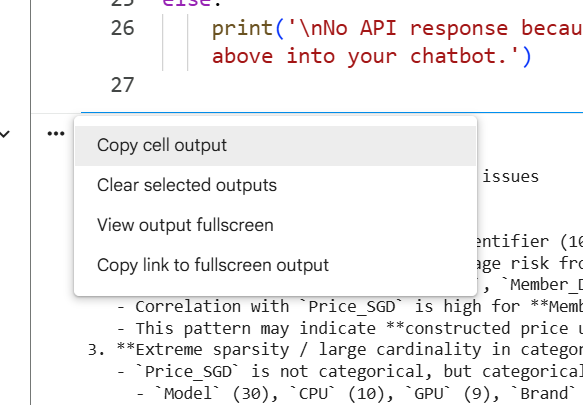

Click "new cell" when you mouseover between this and next cell".

Click on "generate" with AI. This is important, as it allows Gemini to know where do you want the code to be inserted or transformed. If not, Gemini may insert the code anywhere it deems fit.

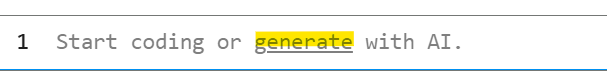

Type on Gemini chat window to "Generate code to fix each of the following issues, only for data cleaning purposes, do not model yet.
Input is df, and output should be cleaned_df." Then paste the earlier output response, which describes the issues identified.

In [ ]:
# -----------------------------
# Note: The following is an example generated by the tutor.
# Do try it out yourselves.
# -----------------------------

cleaned_df = df.copy()

# 1. Reverse the discounts to estimate the original price (Fixes Issue 3: Leakage)
# Formula: original price = (discounted price + fixed discounts) / (1 - percentage discount)
price_after_fixed_discounts = (
    cleaned_df['Price_SGD']
    + cleaned_df['Member_Discount']
    + cleaned_df['Brand_Discount']
)

discount_multiplier = 1 - (cleaned_df['Discount_percent'] / 100)
cleaned_df['Price_SGD'] = (price_after_fixed_discounts / discount_multiplier).round(2)

print('Step 1: Price_SGD adjusted to estimated original price.')

# 2. Drop the original discount columns to prevent target leakage/dominance
columns_to_drop = ['Member_Discount', 'Brand_Discount', 'Discount_percent']
cleaned_df = cleaned_df.drop(columns=columns_to_drop)

print('Step 2: Discount columns dropped.')

# 3. Drop ID-like columns (Unnamed: 0) (Fixes Issue 1 & 6)
unnamed_cols = [col for col in cleaned_df.columns if 'unnamed' in col.lower()]
cleaned_df = cleaned_df.drop(columns=unnamed_cols)

print(f'Step 3: ID-like columns dropped: {unnamed_cols}')

# 4. Drop constant columns (Storage_Type) (Fixes Issue 2)
constant_cols = [col for col in cleaned_df.columns if cleaned_df[col].nunique(dropna=False) <= 1]
cleaned_df = cleaned_df.drop(columns=constant_cols)

print(f'Step 4: Constant columns dropped: {constant_cols}')

# Final Check
print(f'\nOriginal shape: {df.shape}')
print(f'Cleaned shape: {cleaned_df.shape}')
display(cleaned_df.head())

#Note Issue 1,2,3... came from tutor's OpenAI API response. It will not be the same as your own query and response.

###<font color='red'>Activity:</font>

Now, lets try with ChatGPT. You have done something similar during APREP. Copy and modify the output as code to clean your dataset.

In [ ]:
quality_prompt2 = f"""
Generate code to fix each of the following issues, only for data cleaning purposes, do not model yet.
Input is df, and output should be cleaned_df.
Issues:
{response.output_text}
"""


if client is not None:
    response2 = client.responses.create(
        model=OPENAI_MODEL,
        input=quality_prompt2
    )
    print('\nLLM response:')
    print(response2.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

# This cell asks the LLM to generate Python code for data cleaning.
# It uses the earlier LLM response, response.output_text, as the list of issues to fix.
# The instruction says not to build a model yet, only prepare a cleaned version of the data.
# The expected input is df, and the expected output is cleaned_df.
# If the API client is connected, the code suggestion is generated automatically.
# Otherwise, students can copy the prompt and use the chatbot manually.

In [ ]:
# -----------------------------
# Note: The following is an example generated by the tutor.
# Do try it out yourselves.
# You most likely have to delete the text header and footer.
# -----------------------------

import numpy as np
import pandas as pd

# Input: df
# Output: cleaned_df
df = df.copy()

# -----------------------------
# Helper: safe column checks
# -----------------------------
def _drop_if_exists(dframe, cols):
    cols = [c for c in cols if c in dframe.columns]
    if cols:
        dframe = dframe.drop(columns=cols)
    return dframe

# -----------------------------
# 1) Handle ID-like column present
# -----------------------------
# Drop Unnamed: 0 if it looks like an index (high uniqueness, no missing)
if "Unnamed: 0" in df.columns:
    col = df["Unnamed: 0"]
    is_index_like = (col.isna().sum() == 0) and (col.nunique(dropna=True) == len(df))
    if is_index_like:
        df = _drop_if_exists(df, ["Unnamed: 0"])

# -----------------------------
# 2) Potentially redundant / target-leakage risk from discount fields
# -----------------------------
# Data-cleaning approach (no modelling):
# - If Discount_percent is likely derived from other discount fields, drop it to reduce redundancy.
# - Also optionally keep only one "discount percent" representation.
#
# Because we cannot confirm how Price_SGD was generated here, we do a conservative clean:
# - Keep only the two discount components if present; drop Discount_percent.
# - This removes a high-cardinality duplicate of discount information.
drop_cols = []
if "Discount_percent" in df.columns:
    drop_cols.append("Discount_percent")

df = _drop_if_exists(df, drop_cols)

# -----------------------------
# 3) Extreme sparsity / large cardinality in categoricals
# -----------------------------
# Data cleaning only: normalize string casing/whitespace; treat "unknown-ish" consistently.
categorical_cols = []
for c in df.columns:
    if df[c].dtype == "object":
        categorical_cols.append(c)

# Basic cleanup for categorical text
for c in categorical_cols:
    df[c] = (
        df[c]
        .astype(str)
        .str.strip()
        .replace({"nan": np.nan, "None": np.nan})
    )
    # Fill missing category with a single token (even though you said none missing,
    # this is safe for robustness if "nan"/"None" appear as strings)
    df[c] = df[c].fillna("Unknown")

# Optionally drop extremely high-cardinality categoricals if any exist
# (not expected given your notes, but safe cleaning)
high_card = []
for c in categorical_cols:
    nunq = df[c].nunique(dropna=True)
    if nunq > 200:  # heuristic threshold; adjust if needed
        high_card.append(c)
df = _drop_if_exists(df, high_card)

# -----------------------------
# 4) Discount_percent validity check
# -----------------------------
# Already handled by dropping Discount_percent above.

# -----------------------------
# 5) Large mismatch in scale across numeric features
# -----------------------------
# Scaling is not done here (since this is "cleaning only, do not model yet"),
# but we can still clip obvious outliers to improve data validity.
# Use robust clipping based on quantiles for numeric columns.
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

# Robust outlier clipping (only for plausibly bounded numeric features)
# You can tune these; defaults are generally safe for cleaning.
clip_bounds = {
    # do not clip Price_SGD itself as target might be sensitive; only clip predictors
    "Weight_kg": (0.001, 0.999),
    "Screen_Size_inch": (0.001, 0.999),
    "RAM_GB": (0.001, 0.999),
    "Storage_GB": (0.001, 0.999),
    "RAM_Type": None,      # not numeric
    "Storage_Type": None, # not numeric
}

# Apply clipping to numeric predictors only (exclude target if present)
target_candidates = {"Price_SGD", "price_sgd", "Price"}  # if user has alternative naming
target = None
for t in target_candidates:
    if t in df.columns:
        target = t
        break

for c in numeric_cols:
    if c == target:
        continue
    if c in clip_bounds and clip_bounds[c] is not None:
        lo_q, hi_q = clip_bounds[c]
        lo = df[c].quantile(lo_q)
        hi = df[c].quantile(hi_q)
        df[c] = df[c].clip(lower=lo, upper=hi)

# -----------------------------
# 6) Confirm constant and “derived” columns
# -----------------------------
# Drop columns that are constant (no variance) as they add no predictive signal.
# Do this after basic cleanup.
constant_cols = []
for c in df.columns:
    if df[c].nunique(dropna=False) <= 1:
        constant_cols.append(c)
df = _drop_if_exists(df, constant_cols)

# Additional specific check: Storage_Type constant SSD (per your note)
# If it is constant, it's already removed; keep as-is otherwise.

# -----------------------------
# Final: ensure no accidental all-null columns
# -----------------------------
df = df.dropna(axis=1, how="all")

cleaned_df = df


In [ ]:
cleaned_df

In [ ]:
# What to check after cleaning:
# 1. Did the number of rows stay the same?
# 2. Did the discount columns disappear?
# 3. Are there missing values that still need attention?
# 4. Does Price_SGD still exist as the target column?

print('Original rows:', df.shape[0])
print('Cleaned rows:', cleaned_df.shape[0])

print('\nMissing values after cleaning:')
missing_after_cleaning = cleaned_df.isna().sum()
display(missing_after_cleaning.sort_values(ascending=False).head(10))

print('\nColumns after cleaning:')
print(cleaned_df.columns.tolist())


## Chapter 11. Session 1 checkpoint

**Suggested time:** 10 minutes

Before ending Session 1, answer these:

1. What is the target column?
2. What does payload text contain?
3. Which code cell actually sends information to the LLM?
4. What cleaning actions did we apply?
5. Which cleaning actions required judgement?
6. After cleaning, did the number of rows stay the same?
7. Which columns were removed, and why?

### Short recap

In Session 1, you did not try to build the best model.

You prepared the modelling problem:

```text
Understand dataset
→ inspect dataset
→ create payload text
→ ask LLM for support
→ judge the advice
→ apply simple cleaning
```

### Decision point

You are ready for Session 2 only if you can say:

> I know what my target is, what my rows mean, what I cleaned, and why I cleaned it.


In [ ]:
cleaned_df.to_csv('cleaned_laptop_prices.csv', index=False)

print('Saved cleaned dataset as cleaned_laptop_prices.csv')
print('You can use this file in Session 2.')

#Task: Do you know where the csv file is?


---
# Session 2: From cleaned dataset to baseline model

**Target duration:** 130 minutes

Session 1 ended with a cleaned dataset. Session 2 uses that cleaned dataset for modelling.

By the end of Session 2, you should be able to:

- split data into features and target,
- create train and test sets,
- build a preprocessing and modelling pipeline,
- train a baseline decision tree model,
- evaluate the model using MAE, RMSE, and R²,
- use cross-validation to reduce dependence on one lucky split,
- suggest one safe feature engineering improvement.


## Chapter 12. Recap and reload checkpoint

**Suggested time:** 6 minutes

Session 1 saved a cleaned dataset file.

Run this cell at the start of Session 2. This works even if your Colab runtime restarted.

You should see the cleaned dataset with the target column still present.

In [ ]:
# You may run the following code, if you have the cleaned_laptop_prices.csv file. If not, just rerun earlier cells to re-create it.
# cleaned_df = pd.read_csv('cleaned_laptop_prices.csv')

print('Loaded cleaned_laptop_prices.csv.')
print('Cleaned shape:', cleaned_df.shape)
display(cleaned_df.head())

## Chapter 13. Move from data preparation to modelling

**Suggested time:** 4 minutes

We are no longer asking the LLM to clean the dataset. We are now preparing the table for a scikit-learn model.

The model needs:

| Item | Meaning in this notebook |
|---|---|
| `X` | Input features used to predict price |
| `y` | Target answer, `Price_SGD` |

Example:

If the question is “What is the price of this laptop?”, then:

- `X` contains information such as brand, CPU, RAM, storage, and weight.
- `y` contains the actual price.


<font color='red'>Note:</font> From this point onwards, most work is local scikit-learn modelling work. It is not an LLM prompt unless the code explicitly calls the API.

## Chapter 14. Split into `X` and `y`

**Suggested time:** 8 minutes

This step is for modelling only. It does not send data to the LLM.

`X` should not include the target column. If the answer is inside the input, the model is cheating.


<font color='red'>Common mistake:</font> Do not keep `Price_SGD` inside `X`. That would let the model see the answer while training.

In [ ]:
target_col = 'Price_SGD'

if target_col not in cleaned_df.columns:
    raise ValueError(f'Target column {target_col} was not found. Check your cleaned dataset columns.')

X = cleaned_df.drop(columns=[target_col])
y = cleaned_df[target_col]

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Target column:', target_col)
display(X.head())
display(y.head())

# This cell separates the dataset into INPUT features X and OUTPUT target y.
# target_col stores the column we want the model to predict, which is Price_SGD.
# The if-statement checks that Price_SGD still exists after data cleaning.
# X contains all columns except the target column.
# y contains only the target column.
# The shape outputs help us check how many rows and columns are being used for modelling.

## Chapter 15. Train-test split

**Suggested time:** 15 minutes

We split the data so that the model is tested on rows it did not train on.

| Dataset part | Purpose |
|---|---|
| Training set | Used to learn patterns |
| Test set | Used to check performance on unseen rows |

Example:

If you practise using the exact same test paper and then take the same test, your score may look too good. A separate test set gives a fairer check.


### <font color='blue'>Illustration: why a holdout set matters</font>

The diagram below is the original visual reminder from the practical. Use it to separate three ideas:

* **training data**: rows the model learns from,
* **test data**: held-out rows used for evaluation,
* **deployment data**: future real-world rows that may look different.


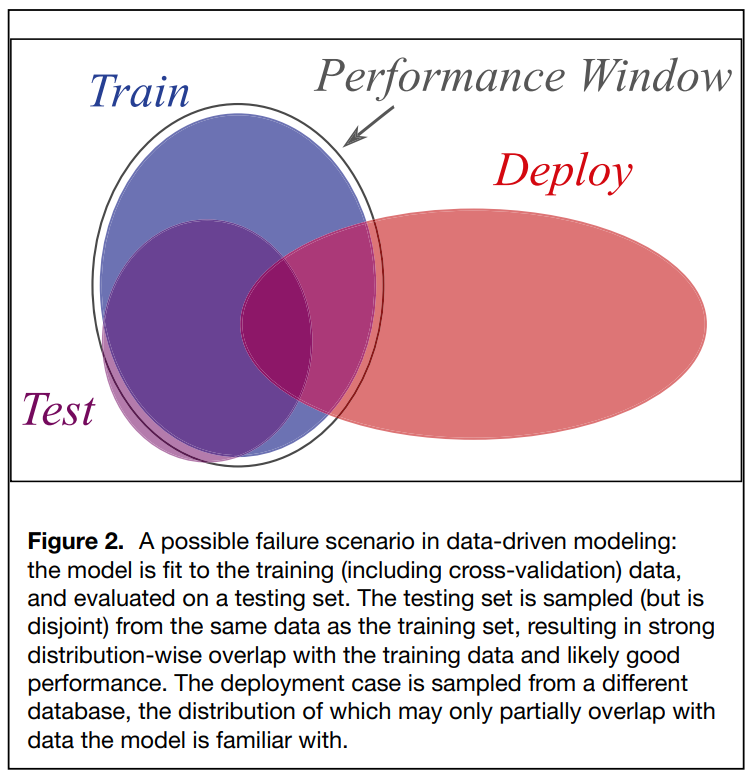

### How to read this diagram and why it matters

This diagram shows **three different data regions** that a model encounters in practice: training, testing, and deployment.

### Train

Training data is what you use to fit the model.

* The model sees this data many times.
* It becomes familiar with this region.
* Performance here is usually higher than real-world performance.

### Test

The test set is held out from training.

A good test score mainly means:

> “The model handles this dataset reasonably well.”

It does **not** guarantee real-world success.

### Deploy

Deployment data represents future real usage.

This is where many models fail:

* accuracy can drop,
* predictions can become unreliable,
* the model still outputs numbers even when it is outside its comfort zone.

<font color='red'>Main takeaway:</font> A train-test split is necessary, but it is not the final proof that the model is safe for real use. It is only the first fair check.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, #0.2 = 20%
    random_state=42
)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])


## Chapter 16. Identify numeric and categorical columns

**Suggested time:** 7 minutes

Before building the model, we separate columns by type.

| Column type | Example handling |
|---|---|
| Numeric | Scale using `StandardScaler` |
| Categorical | Convert using `OneHotEncoder` |

This helps scikit-learn handle both numbers and text categories in one pipeline.


<font color='red'>Note:</font> `OneHotEncoder` is used for categorical features. `StandardScaler` is used for numeric features. For tree-based models, scaling is not always necessary, but using a consistent pipeline is still a good habit.

In [ ]:
cat_columns = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_columns = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

print('Categorical columns:', cat_columns)
print('Numeric columns:', num_columns)
# This cell separates the input columns by data type.
# cat_columns stores text/category columns, such as brand or CPU type.
# num_columns stores numeric columns, such as RAM, storage, or weight.
# This is needed because categorical and numeric columns usually need different preprocessing steps.

## Chapter 17. Build the preprocessing pipeline

**Suggested time:** 8 minutes

A pipeline keeps preprocessing and modelling together.

This is safer than manually transforming the data in many separate places.

### Why it matters

If you transform training data one way and test data another way, your evaluation may become unfair or broken.

A pipeline makes the process repeatable.


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_columns),
        ('num', StandardScaler(), num_columns)
    ],
    remainder='drop'
)

preprocessor

# This cell creates the preprocessing steps before modelling.
# OneHotEncoder changes categorical columns into numeric 0/1 columns.
# handle_unknown='ignore' prevents errors if new unseen categories appear later during testing/deployment.
# StandardScaler scales numeric columns so they are on a more similar range.
# ColumnTransformer applies the correct preprocessing to each column group.
# remainder='drop' means columns not listed in cat_columns or num_columns will be removed.

## Chapter 18. Train a simple baseline model

**Suggested time:** 9 minutes

A baseline model is the first working model. It does not need to be the best model.

The purpose is to give us a fair starting point for comparison.

Here we use a decision tree regressor because it is easy to explain and works with mixed types after preprocessing.


<font color='red'>Practical test reminder:</font> A simple baseline is better than a complicated model that you cannot explain or evaluate properly.

In [ ]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42, max_depth=5))
])

baseline_model.fit(X_train, y_train)
print('Baseline model trained.')


## Chapter 19. Evaluate the baseline model

**Suggested time:** 12 minutes

We use three common regression metrics.

| Metric | Plain meaning | Better when |
|---|---|---|
| MAE | Average absolute error in dollars | Lower is better |
| RMSE | Error that punishes large mistakes more | Lower is better |
| R² | How much variation is explained | Higher is better |

For business explanation, MAE is often easiest because it is in the same unit as the target: Singapore dollars.


In [ ]:
y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

baseline_results = pd.DataFrame({
    'Model': ['Baseline Decision Tree'],
    'MAE': [mae],
    'RMSE': [rmse],
    'R2': [r2]
})

display(baseline_results.round(3))

# This cell uses the trained baseline model to predict laptop prices on the test set.
# y_pred stores the predicted prices.
# MAE shows the average absolute prediction error in dollars.
# RMSE also measures prediction error, but gives more penalty to large errors.
# R2 shows how much of the price variation is explained by the model.
# baseline_results stores the metrics in a simple table for comparison later.

## Chapter 20. Interpret prediction errors

**Suggested time:** 8 minutes

An MAE of 100 means that, on average, the model is about $100 away from the actual price.

It does **not** mean every prediction is exactly $100 wrong.

Some predictions may be close. Some may be very far.

Let us inspect a few individual predictions.


In [ ]:
error_df = X_test.copy()
error_df['Actual_Price_SGD'] = y_test.values
error_df['Predicted_Price_SGD'] = y_pred.round(2)
error_df['Absolute_Error'] = np.abs(error_df['Actual_Price_SGD'] - error_df['Predicted_Price_SGD']).round(2)

# Show largest errors first
error_df_sorted = error_df.sort_values('Absolute_Error', ascending=False)
display(error_df_sorted.head(10))

# This cell creates an error analysis table for the test set.
# It copies X_test so we can view each laptop together with its prediction result.
# Actual_Price_SGD stores the true price from y_test.
# Predicted_Price_SGD stores the model's predicted price.
# Absolute_Error shows how far the prediction is from the actual price.
# Sorting by Absolute_Error helps us inspect the worst prediction mistakes first.

### Mini-activity: explain one error

Pick one row with a large error.

Try to answer:

1. Is the laptop unusual compared with the rest?
2. Does it have a premium brand, CPU, GPU, RAM, or screen size?
3. Is there a possible data issue?
4. What extra feature might help the model?


## Chapter 21. Cross-validation: avoid trusting one lucky split

**Suggested time:** 12 minutes

A single train-test split can be lucky or unlucky.

Cross-validation trains and evaluates the model multiple times using different splits.

In this practical, we use `ShuffleSplit`:

- 10 different splits,
- each split keeps 20% for validation,
- same `random_state` for repeatability.

### Why does scikit-learn use `neg_mean_absolute_error`?

`cross_val_score` is designed to maximise scores.

But MAE is an error, so smaller is better. To fit the scoring system, scikit-learn returns negative MAE.

That is why we use:

```python
cv_mae = -cv_scores
```


In [ ]:
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

cv_scores = cross_val_score(
    baseline_model,
    X,
    y,
    cv=cv,
    scoring='neg_mean_absolute_error'
)

cv_mae = -cv_scores

print('CV MAE scores:', np.round(cv_mae, 2))
print('Mean CV MAE:', round(cv_mae.mean(), 2))
print('Std CV MAE:', round(cv_mae.std(), 2))

# Meaning behind this cell:
# Instead of testing the model only once, cross-validation tests it 10 times using different random train-test splits.
# Each split uses 80% of the data for training and 20% for testing.
# This gives a more reliable view of model performance than one single train-test split.
# scoring='neg_mean_absolute_error' is used because scikit-learn treats higher scores as better.
# Since MAE is an error value, scikit-learn returns it as negative, so we multiply by -1 to get normal MAE values.
# Mean CV MAE shows the average prediction error across the 10 tests.
# Std CV MAE shows how stable or unstable the model performance is across different splits.

## Chapter 22. LLM-assisted feature engineering brainstorm

**Suggested time:** 8 minutes

After a baseline model, you can ask an LLM for feature engineering ideas.

But the LLM should not invent columns that do not exist.

### <font color='blue'>First, think manually</font>

A good feature engineering idea should be computed from existing columns.

Examples:

| Possible feature | Why it might help |
|---|---|
| `RAM_per_kg` | Captures memory relative to laptop weight |
| `Storage_per_kg` | Captures storage relative to portability |
| `is_high_ram` | Flags laptops with unusually high RAM |

### Prompt to use

```text
I am predicting laptop price using the columns listed below.
Suggest 5 engineered features that can be computed only from these columns.
For each feature, explain:
1. why it may help predict price,
2. how to compute it,
3. whether there is any leakage risk.
Keep the answer practical for a beginner data analytics student.
```


## <font color='red'>Note: Practical Test – Why You Are Looking at This Code</font>

In a practical test, you may be asked to prepare simple features or work with categories using the OpenAI API.

The key skill is knowing how to request output in a controlled format and understanding what that output is used for.

## <font color='red'>Note: Project and Industry Practice – How This Code Is Used</font>

For industry-style tasks and pet projects, LLMs can help draft mapping tables or feature groupings.

However, the LLM is a **support tool**, not a decision maker. You are expected to review, adjust, and validate generated ideas before using them in modelling.


In [ ]:
columns_text = '\n'.join(X.columns.tolist())

feature_prompt = f"""
I am predicting laptop price using only these columns:
{columns_text}

Suggest 5 engineered features that can be computed only from these columns.
For each feature, explain:
1. why it may help predict price,
2. how to compute it,
3. whether there is any leakage risk.

Keep the answer practical for a beginner data analytics student.
"""

print('Prompt preview:')
print(feature_prompt)

if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=feature_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')


## Chapter 23. Implement one simple safe feature

**Suggested time:** 5 minutes

We implement one simple feature only, so the main class flow stays manageable.

Example: `RAM_per_kg`

This may capture how much memory the laptop provides relative to its weight. It is not guaranteed to improve performance, but it is easy to test.

### Caveat

Feature engineering is a hypothesis. You must test whether it improves validation performance.


In [ ]:
engineered_df = cleaned_df.copy()

if {'RAM_GB', 'Weight_kg'}.issubset(engineered_df.columns):
    engineered_df['RAM_per_kg'] = engineered_df['RAM_GB'] / engineered_df['Weight_kg']
    print('Created RAM_per_kg.')
else:
    print('RAM_GB or Weight_kg not found. No engineered feature created.')

engineered_df.head()


## Chapter 24. Create files for manual GitHub upload

**Suggested time:** 23 minutes

This section creates the files that you will upload manually to GitHub after Week 3.

Week 4 will continue from these files, so do not upload only the notebook. The important Week 4 starting files are:

| File | Why Week 4 needs it |
|---|---|
| `train_features.csv` | The Week 3 training predictors |
| `test_features.csv` | The Week 3 test predictors |
| `train_target.csv` | The Week 3 training target |
| `test_target.csv` | The Week 3 test target |
| `cleaned_laptop_prices.csv` | The cleaned dataset before modelling |
| `engineered_laptop_prices.csv` | The dataset with simple engineered features |
| `README.md` | A short explanation of what the files are |

Use a simple GitHub folder name such as:

```text
week3_github_upload
```

In Week 4, you will load these CSV files from GitHub raw links.

In [ ]:
export_folder = 'week3_github_upload'
os.makedirs(export_folder, exist_ok=True)

cleaned_df.to_csv(export_folder + '/cleaned_laptop_prices.csv', index=False)
engineered_df.to_csv(export_folder + '/engineered_laptop_prices.csv', index=False)

X_train.to_csv(export_folder + '/train_features.csv', index=False)
X_test.to_csv(export_folder + '/test_features.csv', index=False)
y_train.to_csv(export_folder + '/train_target.csv', index=False)
y_test.to_csv(export_folder + '/test_target.csv', index=False)

baseline_predictions = pd.DataFrame()
baseline_predictions['actual_price'] = y_test.values
baseline_predictions['predicted_price'] = y_pred
baseline_predictions['error'] = baseline_predictions['predicted_price'] - baseline_predictions['actual_price']
baseline_predictions['absolute_error'] = baseline_predictions['error'].abs()
baseline_predictions.to_csv(export_folder + '/baseline_predictions.csv', index=False)

baseline_metrics = pd.DataFrame({
    'metric': ['MAE', 'RMSE', 'R2'],
    'value': [mae, rmse, r2]
})
baseline_metrics.to_csv(export_folder + '/baseline_metrics.csv', index=False)

joblib.dump(baseline_model, export_folder + '/baseline_model.joblib')

readme_text = '''# ADALL Week 3 Lab Outputs

This folder contains files created at the end of Week 3.

Week 4 should load these files from GitHub:

- train_features.csv
- test_features.csv
- train_target.csv
- test_target.csv

These files keep the same train-test split from Week 3, so Week 4 can focus on modelling and evaluation instead of repeating data preparation.

Other useful files:

- cleaned_laptop_prices.csv
- engineered_laptop_prices.csv
- baseline_predictions.csv
- baseline_metrics.csv
- cross_validation_scores.csv
- baseline_model.joblib

Do not upload private keys, passwords, or Colab secrets to GitHub.
'''

with open(export_folder + '/README.md', 'w') as file:
    file.write(readme_text)

print('Files created in:', export_folder)
print(os.listdir(export_folder))

In [ ]:
#create zip
!zip -r week3_github_upload.zip week3_github_upload

###How to manually upload:
1. Download and unzip the files in your local desktop. The files will be found in a folder. For example: C:\Users\ruiqu\Downloads\week3_github_upload

2. Go to your Github ADALL_github repo. If you do not have it, refer to previous week material on how to create a repo.

3. Add file.

4. Drag the folder (NOT the files) into the drop area.
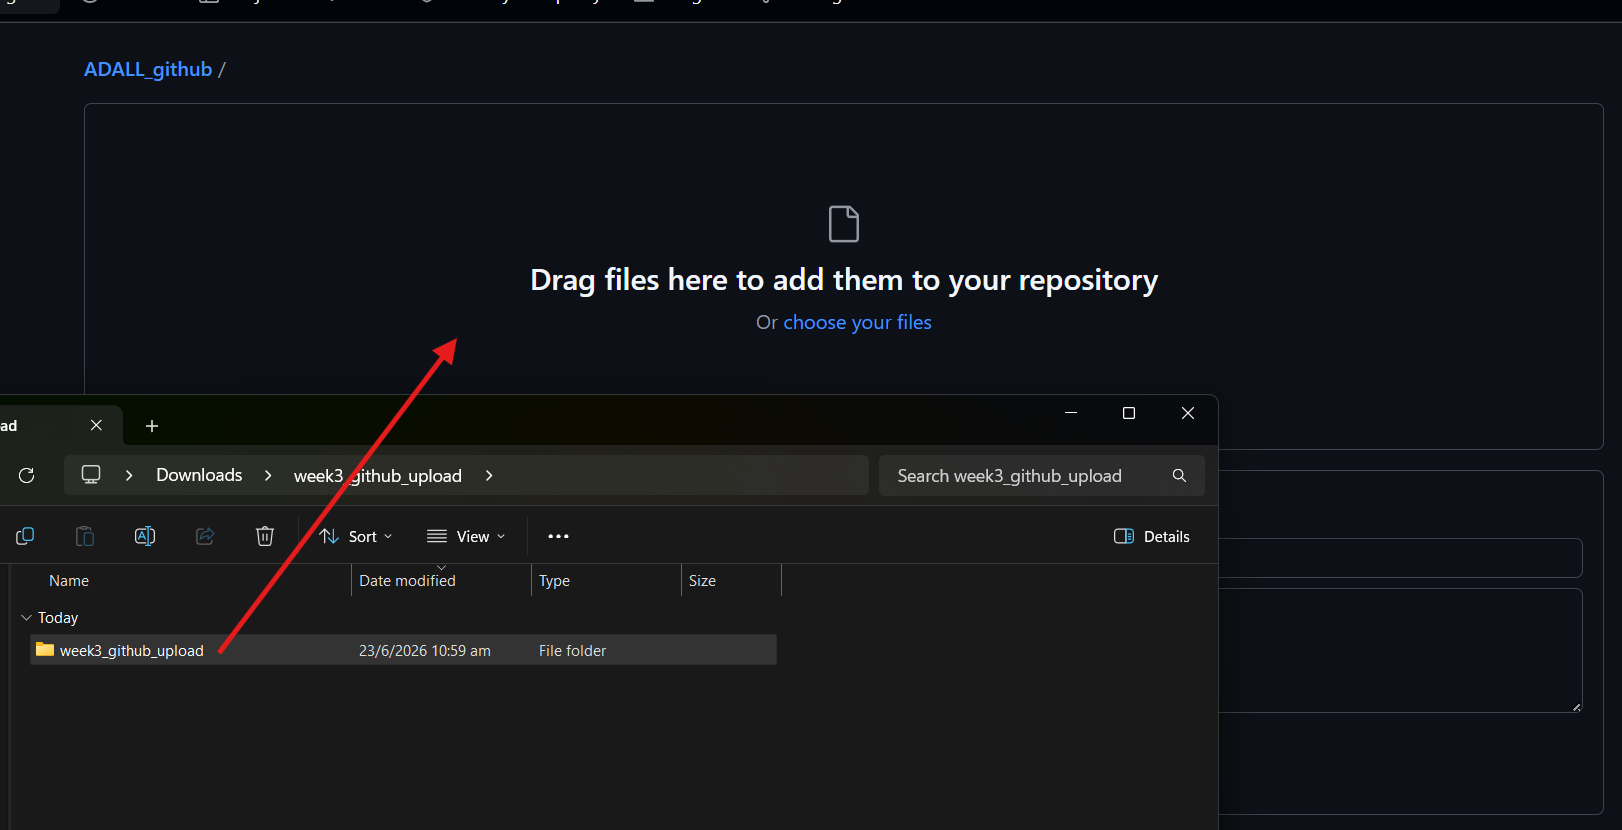

## Chapter 25. Session 2 consolidation

**Suggested time:** 5 minutes

Answer these before ending:

1. Why do we need a baseline model?
2. Why do we split into `X` and `y`?
3. Why is cross-validation more stable than one train-test split?
4. What does MAE mean in this laptop pricing task?
5. What is one feature engineering idea you would test next?

You now have the core workflow. The Additional Practice section extends it, but it should not be forced into the 130-minute class block.


---
# Additional Practice: self-paced extension

This section is **not part of the 130-minute Session 2 core flow**.

Use it after class or for stronger students who finish early.


## A1. Compare original baseline vs engineered dataset

This tests whether the simple engineered feature helped.


In [ ]:
# Only run this if engineered_df has the target column.
X_eng = engineered_df.drop(columns=[target_col])
y_eng = engineered_df[target_col]

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42
)

cat_columns_eng = X_train_eng.select_dtypes(include=['object', 'category']).columns.tolist()
num_columns_eng = X_train_eng.select_dtypes(exclude=['object', 'category']).columns.tolist()

preprocessor_eng = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_columns_eng),
        ('num', StandardScaler(), num_columns_eng)
    ]
)

engineered_model = Pipeline(steps=[
    ('preprocessor', preprocessor_eng),
    ('model', DecisionTreeRegressor(random_state=42, max_depth=5))
])

engineered_model.fit(X_train_eng, y_train_eng)
y_pred_eng = engineered_model.predict(X_test_eng)

engineered_results = pd.DataFrame({
    'Model': ['Engineered Decision Tree'],
    'MAE': [mean_absolute_error(y_test_eng, y_pred_eng)],
    'RMSE': [np.sqrt(mean_squared_error(y_test_eng, y_pred_eng))],
    'R2': [r2_score(y_test_eng, y_pred_eng)]
})

comparison = pd.concat([baseline_results, engineered_results], ignore_index=True)
display(comparison.round(3))


## A2. Small grid search

Grid search tests a small set of model settings.

Do not treat this as magic. It only tests the settings you provide.


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__max_depth': [3, 5, 8, None],
    'model__min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    estimator=baseline_model,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid.fit(X, y)

print('Best parameters:', grid.best_params_)
print('Best CV MAE:', round(-grid.best_score_, 2))


## A3. <font color='blue'>Prompt for model comparison</font>

Use this only after you have baseline results.

```text
I trained a baseline decision tree regression model for laptop price prediction.
My MAE is [insert value].
My RMSE is [insert value].
My R² is [insert value].
Suggest 3 next modelling improvements.
For each improvement, explain the expected benefit and the risk of overfitting.
Do not suggest anything that requires columns I do not have.
```


---

# A4. Optional Reading: Dataset Checks Are Warnings, Not Rules

When using an LLM to review a dataset, we usually send a **dataset profile** or **payload text**, not the full dataset.

A dataset profile is useful because it is shorter, faster, cheaper, and safer. It gives the LLM enough information to comment on common issues such as missing values, possible outliers, high-cardinality columns, and modelling readiness.

However, payload text is not perfect. It may hide row-level patterns, rare cases, or unusual combinations of values. If the task depends on exact records, use Python analysis instead of relying only on the LLM summary.

Sending the full dataset may be inappropriate because it may be slow, it may cost more tokens, it may create privacy and governance risk, and the LLM may not need every row to answer a high-level readiness question.

Use a dataset profile first. Send only the information needed for the task.

Correlation, outliers, high-cardinality columns, and unique-value columns are useful checks, but they do not automatically decide what to drop.

For example, a unique `Order_ID` is usually not useful for prediction. A unique or near-unique `Price_SGD` value may be valid because prices naturally vary. A high-cardinality product model column may be useful for price prediction, but it may also cause memorisation. An outlier may be a valid premium laptop rather than an error. A negative price is probably invalid. A $999,999 laptop price may be a data entry error.

<font color='red'>Good practice:</font> treat each warning as a reason to inspect, not as a command to remove.

A column with many unique values is not automatically bad.

For example, product model names may be very predictive of laptop price. But if the model memorises old product names, it may fail when new products appear.

This is why you inspect, test, and compare.

A good modelling decision should consider whether the value is possible in the real world, whether the column is available at prediction time, whether the column helps the model generalise, and whether removing or keeping it improves the result in a fair test.

## Suggested links for further reading

* OpenAI API documentation: data sent to the model and prompt design
* Pandas documentation: `describe()`, `isna()`, `nunique()`, and data inspection
* scikit-learn documentation: train-test split, preprocessing, and model evaluation
* scikit-learn documentation: common pitfalls and data leakage
* PDPC Singapore resources: personal data protection and data minimisation
